# Linear-Quadratic Mean-Field Control
## Continuous Gaussian Benchmark

This notebook rebuilds the archived LQ examples around a reusable continuous environment. It is a benchmark and diagnostics scaffold for future continuous-state algorithms, not a finite-state simplex experiment.

The saved notebook is output-free and ready to run from top to bottom.

## Imports

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, Optional, Tuple
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = (ROOT / "..").resolve()
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

from mfc.environments import LQConfig, LinearQuadraticMFC


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64
torch.set_default_dtype(DTYPE)


def set_seed(seed: int) -> None:
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if device.type == "cuda":
        torch.cuda.manual_seed_all(seed)


set_seed(7)
print(f"device: {device}")


device: cuda


## Model Recap

The benchmark uses a one-dimensional Gaussian mean-field model:

`X[t+1] = a X[t] + b U[t] + c m[t] + sigma eps[t+1]`, where `m[t] = E[X[t]]`.

The policy is Gaussian feedback with fixed variance:

`U[t] ~ Normal(theta[t, 0] X[t] + theta[t, 1] m[t], policy_std^2)`.

The objective is a finite-horizon cost. All diagnostics below minimize this cost and reserve exact formulas for validation.

## Environment Setup

In [3]:
config = LQConfig(device=device, dtype=DTYPE)
env = LinearQuadraticMFC(config)

theta_zero = env.zero_policy()
theta_riccati = env.riccati_policy()
cost_zero, grad_zero = env.exact_gradient(theta_zero)
cost_riccati, grad_riccati = env.exact_gradient(theta_riccati)
mean_riccati, variance_riccati = env.exact_moments(theta_riccati)

benchmark_table = pd.DataFrame(
    [
        {
            "policy": "zero",
            "exact_cost": float(cost_zero.cpu()),
            "grad_norm": float(torch.linalg.vector_norm(grad_zero).cpu()),
            "theta_norm": float(torch.linalg.vector_norm(theta_zero).cpu()),
        },
        {
            "policy": "riccati",
            "exact_cost": float(cost_riccati.cpu()),
            "grad_norm": float(torch.linalg.vector_norm(grad_riccati).cpu()),
            "theta_norm": float(torch.linalg.vector_norm(theta_riccati).cpu()),
        },
    ]
)
display(benchmark_table.round(6))


,policy,exact_cost,grad_norm,theta_norm
0,zero,5.022146,5.069627,0.000000
1,riccati,2.672333,0.000000,2.435308


## Exact Gradient Sanity Check

In [4]:
def finite_difference_gradient(env: LinearQuadraticMFC, theta: torch.Tensor, eps: float = 1e-6) -> torch.Tensor:
    finite_difference = torch.empty_like(theta)
    for index in range(theta.numel()):
        step = torch.zeros_like(theta).reshape(-1)
        step[index] = eps
        step = step.reshape_as(theta)
        finite_difference.reshape(-1)[index] = (
            env.exact_cost(theta + step) - env.exact_cost(theta - step)
        ) / (2.0 * eps)
    return finite_difference


def tensor_cosine(left: torch.Tensor, right: torch.Tensor) -> float:
    numerator = torch.dot(left.reshape(-1), right.reshape(-1))
    denominator = torch.linalg.vector_norm(left) * torch.linalg.vector_norm(right) + 1e-12
    return float((numerator / denominator).detach().cpu())


def relative_error(estimate: torch.Tensor, target: torch.Tensor) -> float:
    value = torch.linalg.vector_norm(estimate - target) / (torch.linalg.vector_norm(target) + 1e-12)
    return float(value.detach().cpu())


set_seed(11)
theta_eval = theta_riccati + 0.05 * torch.randn_like(theta_riccati)
cost_eval, exact_grad_eval = env.exact_gradient(theta_eval)
finite_diff_grad = finite_difference_gradient(env, theta_eval)

gradient_check = pd.DataFrame(
    [
        {
            "theta": "riccati + noise",
            "exact_cost": float(cost_eval.cpu()),
            "max_abs_error": float((exact_grad_eval - finite_diff_grad).abs().max().cpu()),
            "relative_error": relative_error(finite_diff_grad, exact_grad_eval),
            "cosine": tensor_cosine(finite_diff_grad, exact_grad_eval),
        }
    ]
)
display(gradient_check.round(8))


,theta,exact_cost,max_abs_error,relative_error,cosine
0,riccati + noise,2.673854,0.0,2.000000e-08,1.0


## Monte Carlo Trajectory Simulation

In [5]:
def monte_carlo_cost(batch: Dict[str, torch.Tensor]) -> torch.Tensor:
    return (batch["stage_costs"].sum(dim=1) + batch["terminal_costs"]).mean()


mc_batch_size = 20_000
mc_batch = env.sample_trajectories(theta_eval, n=mc_batch_size, seed=101)
mc_cost = monte_carlo_cost(mc_batch)

mc_summary = pd.DataFrame(
    [
        {
            "n_trajectories": mc_batch_size,
            "monte_carlo_cost": float(mc_cost.cpu()),
            "exact_cost": float(cost_eval.cpu()),
            "absolute_error": float((mc_cost - cost_eval).abs().cpu()),
        }
    ]
)
display(mc_summary.round(6))

moment_summary = pd.DataFrame(
    {
        "t": np.arange(config.T + 1),
        "exact_mean": mc_batch["mean_flow"].detach().cpu().numpy(),
        "sample_mean": mc_batch["states"].mean(dim=0).detach().cpu().numpy(),
        "exact_variance": env.exact_moments(theta_eval)[1].detach().cpu().numpy(),
        "sample_variance": mc_batch["states"].var(dim=0, unbiased=False).detach().cpu().numpy(),
    }
)
display(moment_summary.round(6))


,n_trajectories,monte_carlo_cost,exact_cost,absolute_error
0,20000,2.685055,2.673854,0.011201


,t,exact_mean,sample_mean,exact_variance,sample_variance
0,0,0.800000,0.805740,0.250000,0.248360
1,1,0.299849,0.299660,0.102921,0.101850
2,2,0.108060,0.106585,0.080481,0.080844
3,3,0.038242,0.036797,0.074643,0.073802
4,4,0.013021,0.014266,0.075251,0.075784
5,5,0.004218,0.002950,0.074714,0.075466
6,6,0.001657,0.001601,0.076474,0.076569
7,7,0.000728,-0.000126,0.079054,0.077861
8,8,0.000239,-0.001190,0.075206,0.074493


## Frozen-Flow REINFORCE Diagnostic

This checks the known baseline behavior from the archived notebooks: vanilla REINFORCE estimates the policy-score gradient for a frozen law input. That gradient can differ from the full mean-field gradient because the population flow itself depends on `theta`.

In [6]:
def returns_to_go(batch: Dict[str, torch.Tensor]) -> torch.Tensor:
    returns = torch.empty_like(batch["stage_costs"])
    running = batch["terminal_costs"].clone()
    for t in range(batch["stage_costs"].shape[1] - 1, -1, -1):
        running = batch["stage_costs"][:, t] + running
        returns[:, t] = running
    return returns


def reinforce_gradient(
    env: LinearQuadraticMFC,
    theta: torch.Tensor,
    n_trajectories: int,
    seed: int,
    frozen_mean_flow: Optional[torch.Tensor] = None,
) -> torch.Tensor:
    batch = env.sample_trajectories(theta, n=n_trajectories, seed=seed, frozen_mean_flow=frozen_mean_flow)
    returns = returns_to_go(batch)
    grad = torch.zeros_like(theta)
    for t in range(env.config.T):
        scores = env.policy_score_batch(
            theta,
            t,
            batch["states"][:, t],
            batch["law_means"][:, t],
            batch["actions"][:, t],
            action_means=batch["action_means"][:, t],
        )
        advantages = returns[:, t] - returns[:, t].mean()
        grad = grad + (scores * advantages[:, None, None]).mean(dim=0)
    return grad.detach()


def average_reinforce_gradient(
    env: LinearQuadraticMFC,
    theta: torch.Tensor,
    n_trajectories: int,
    n_seeds: int,
    seed0: int,
    frozen_mean_flow: Optional[torch.Tensor] = None,
) -> Tuple[torch.Tensor, torch.Tensor]:
    gradients = []
    for offset in range(n_seeds):
        gradients.append(
            reinforce_gradient(
                env,
                theta,
                n_trajectories=n_trajectories,
                seed=seed0 + offset,
                frozen_mean_flow=frozen_mean_flow,
            )
        )
    stacked = torch.stack(gradients)
    return stacked.mean(dim=0), stacked.std(dim=0, unbiased=False)


def frozen_flow_cost(env: LinearQuadraticMFC, theta: torch.Tensor, frozen_mean_flow: torch.Tensor) -> torch.Tensor:
    cfg = env.config
    theta = torch.as_tensor(theta, dtype=cfg.dtype, device=cfg.device)
    law = torch.as_tensor(frozen_mean_flow, dtype=cfg.dtype, device=cfg.device)
    mean = torch.as_tensor(cfg.x0_mean, dtype=theta.dtype, device=theta.device)
    variance = torch.as_tensor(cfg.x0_std**2, dtype=theta.dtype, device=theta.device)
    total = torch.zeros((), dtype=theta.dtype, device=theta.device)
    for t in range(cfg.T):
        state_second_moment = variance + mean.square()
        action_mean = theta[t, 0] * mean + theta[t, 1] * law[t]
        action_second_moment = action_mean.square() + theta[t, 0].square() * variance + cfg.policy_std**2
        total = total + cfg.q * state_second_moment + cfg.r * action_second_moment + cfg.gamma * law[t].square()
        fluctuation_factor = cfg.a + cfg.b * theta[t, 0]
        mean = fluctuation_factor * mean + (cfg.b * theta[t, 1] + cfg.c) * law[t]
        variance = fluctuation_factor.square() * variance + cfg.b**2 * cfg.policy_std**2 + cfg.noise_std**2
    return total + cfg.q_T * (variance + mean.square()) + cfg.gamma_T * law[cfg.T].square()


def frozen_flow_gradient(
    env: LinearQuadraticMFC,
    theta: torch.Tensor,
    frozen_mean_flow: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor]:
    theta_var = theta.detach().clone().requires_grad_(True)
    cost = frozen_flow_cost(env, theta_var, frozen_mean_flow)
    grad = torch.autograd.grad(cost, theta_var)[0]
    return cost.detach(), grad.detach()


In [7]:
diagnostic_batch_size = 16_384
diagnostic_seeds = 8
mean_flow_eval = env.exact_moments(theta_eval)[0].detach()
frozen_cost_eval, frozen_grad_eval = frozen_flow_gradient(env, theta_eval, mean_flow_eval)
reinforce_grad_mean, reinforce_grad_std = average_reinforce_gradient(
    env,
    theta_eval,
    n_trajectories=diagnostic_batch_size,
    n_seeds=diagnostic_seeds,
    seed0=1_000,
    frozen_mean_flow=mean_flow_eval,
)

reinforce_diagnostic = pd.DataFrame(
    [
        {
            "comparison": "REINFORCE vs frozen-flow gradient",
            "cosine": tensor_cosine(reinforce_grad_mean, frozen_grad_eval),
            "relative_error": relative_error(reinforce_grad_mean, frozen_grad_eval),
            "reference_norm": float(torch.linalg.vector_norm(frozen_grad_eval).cpu()),
        },
        {
            "comparison": "REINFORCE vs full mean-field gradient",
            "cosine": tensor_cosine(reinforce_grad_mean, exact_grad_eval),
            "relative_error": relative_error(reinforce_grad_mean, exact_grad_eval),
            "reference_norm": float(torch.linalg.vector_norm(exact_grad_eval).cpu()),
        },
    ]
)
display(reinforce_diagnostic.round(6))

print(f"diagnostic batch size per seed: {diagnostic_batch_size}")
print(f"diagnostic seeds: {diagnostic_seeds}")
print(f"mean coordinate REINFORCE std: {reinforce_grad_std.mean().item():.6e}")


,comparison,cosine,relative_error,reference_norm
0,REINFORCE vs frozen-flow gradient,0.997758,0.155975,0.125175
1,REINFORCE vs full mean-field gradient,-0.885292,3.194334,0.047147


diagnostic batch size per seed: 16384
diagnostic seeds: 8
mean coordinate REINFORCE std: 6.297770e-03


## REINFORCE vs Mean-Field-Aware REINFORCE

The archive-style comparison below uses a stronger mean-field coupling than the default smoke-test configuration above, so the missing population-flow term is visible. Classical REINFORCE uses only the policy-score term and treats the current population mean flow as frozen inside each update. The mean-field-aware variant adds a sampled sensitivity estimate for the population mean flow before taking the same Adam step. Both methods are evaluated afterward with the exact LQ objective, exact full gradient, and Riccati optimum for this comparison environment.


In [ ]:
def frozen_flow_law_gradient(
    env: LinearQuadraticMFC,
    theta: torch.Tensor,
    frozen_mean_flow: torch.Tensor,
) -> Tuple[torch.Tensor, torch.Tensor]:
    law_var = frozen_mean_flow.detach().clone().requires_grad_(True)
    cost = frozen_flow_cost(env, theta.detach(), law_var)
    grad_law = torch.autograd.grad(cost, law_var)[0]
    return cost.detach(), grad_law.detach()


def mean_flow_jacobian_reinforce(
    env: LinearQuadraticMFC,
    theta: torch.Tensor,
    n_trajectories: int,
    seed: int,
) -> torch.Tensor:
    batch = env.sample_trajectories(theta, n=n_trajectories, seed=seed)
    jacobian = torch.zeros(
        (env.config.T + 1, *theta.shape),
        dtype=theta.dtype,
        device=theta.device,
    )
    cumulative_scores = torch.zeros(
        (n_trajectories, *theta.shape),
        dtype=theta.dtype,
        device=theta.device,
    )

    for t in range(env.config.T):
        scores = env.policy_score_batch(
            theta,
            t,
            batch["states"][:, t],
            batch["law_means"][:, t],
            batch["actions"][:, t],
            action_means=batch["action_means"][:, t],
        )
        cumulative_scores = cumulative_scores + scores
        centered_states = batch["states"][:, t + 1] - batch["states"][:, t + 1].mean()
        jacobian[t + 1] = (centered_states[:, None, None] * cumulative_scores).mean(dim=0)

    return jacobian.detach()


def mean_field_reinforce_gradient(
    env: LinearQuadraticMFC,
    theta: torch.Tensor,
    n_trajectories: int,
    seed: int,
) -> torch.Tensor:
    mean_flow = env.exact_moments(theta)[0].detach()
    direct_gradient = reinforce_gradient(
        env,
        theta,
        n_trajectories=n_trajectories,
        seed=seed,
        frozen_mean_flow=mean_flow,
    )
    _, law_gradient = frozen_flow_law_gradient(env, theta, mean_flow)
    mean_jacobian = mean_flow_jacobian_reinforce(
        env,
        theta,
        n_trajectories=n_trajectories,
        seed=seed + 100_000,
    )
    correction = (law_gradient[:, None, None] * mean_jacobian).sum(dim=0)
    return (direct_gradient + correction).detach()


def average_training_gradient(
    method: str,
    env: LinearQuadraticMFC,
    theta: torch.Tensor,
    n_trajectories: int,
    n_seeds: int,
    seed0: int,
) -> torch.Tensor:
    gradients = []
    for offset in range(n_seeds):
        seed = seed0 + offset
        if method == "reinforce":
            mean_flow = env.exact_moments(theta)[0].detach()
            gradient = reinforce_gradient(
                env,
                theta,
                n_trajectories=n_trajectories,
                seed=seed,
                frozen_mean_flow=mean_flow,
            )
        elif method == "mean_field":
            gradient = mean_field_reinforce_gradient(env, theta, n_trajectories, seed)
        else:
            raise ValueError(f"Unknown method={method!r}.")
        gradients.append(gradient)
    return torch.stack(gradients).mean(dim=0)


def clip_gradient(gradient: torch.Tensor, max_norm: float) -> torch.Tensor:
    norm = torch.linalg.vector_norm(gradient)
    scale = min(1.0, max_norm / (float(norm.cpu()) + 1e-12))
    return gradient * scale


def exact_training_metrics(env: LinearQuadraticMFC, theta: torch.Tensor, theta_reference: torch.Tensor) -> Dict[str, float]:
    cost, gradient = env.exact_gradient(theta)
    reference_cost, _ = env.exact_gradient(theta_reference)
    return {
        "cost": float(cost.cpu()),
        "gap_to_riccati": max(float((cost - reference_cost).cpu()), 0.0),
        "grad_norm": float(torch.linalg.vector_norm(gradient).cpu()),
        "theta_distance": float(torch.linalg.vector_norm(theta - theta_reference).cpu()),
    }


def train_lq_reinforce_variant(
    method: str,
    env: LinearQuadraticMFC,
    theta_init: torch.Tensor,
    theta_reference: torch.Tensor,
    n_iterations: int = 400,
    learning_rate: float = 0.02,
    n_trajectories: int = 4_096,
    n_gradient_seeds: int = 1,
    clip_norm: float = 2.0,
    seed0: int = 10_000,
) -> Tuple[torch.Tensor, pd.DataFrame]:
    theta = torch.nn.Parameter(theta_init.detach().clone())
    optimizer = torch.optim.Adam([theta], lr=learning_rate)
    history = []

    for iteration in range(n_iterations + 1):
        metrics = exact_training_metrics(env, theta.detach(), theta_reference)
        metrics["iteration"] = iteration
        history.append(metrics)
        if iteration == n_iterations:
            break

        gradient = average_training_gradient(
            method,
            env,
            theta.detach(),
            n_trajectories=n_trajectories,
            n_seeds=n_gradient_seeds,
            seed0=seed0 + iteration * n_gradient_seeds,
        )
        gradient = clip_gradient(gradient, clip_norm)
        optimizer.zero_grad(set_to_none=True)
        theta.grad = gradient.clone()
        optimizer.step()

    return theta.detach().clone(), pd.DataFrame(history)


In [ ]:
comparison_config = LQConfig(
    device=device,
    dtype=DTYPE,
    T=8,
    a=0.75,
    b=0.45,
    c=0.70,
    noise_std=0.20,
    policy_std=0.35,
    q=1.0,
    r=0.30,
    gamma=2.0,
    q_T=1.5,
    gamma_T=2.0,
    x0_mean=0.80,
    x0_std=0.50,
)
comparison_env = LinearQuadraticMFC(comparison_config)
comparison_theta_init = comparison_env.zero_policy()
comparison_theta_riccati = comparison_env.riccati_policy()

training_comparison_config = {
    "n_iterations": 200,
    "learning_rate": 0.03,
    "n_trajectories": 4_096,
    "n_gradient_seeds": 1,
    "clip_norm": 2.0,
}

theta_reinforce, reinforce_history = train_lq_reinforce_variant(
    "reinforce",
    comparison_env,
    comparison_theta_init,
    comparison_theta_riccati,
    seed0=20_000,
    **training_comparison_config,
)
theta_mean_field, mean_field_history = train_lq_reinforce_variant(
    "mean_field",
    comparison_env,
    comparison_theta_init,
    comparison_theta_riccati,
    seed0=40_000,
    **training_comparison_config,
)

comparison_rows = []
for method, theta in [
    ("Riccati", comparison_theta_riccati),
    ("REINFORCE", theta_reinforce),
    ("MFREINFORCE", theta_mean_field),
]:
    row = {"method": method}
    row.update(exact_training_metrics(comparison_env, theta, comparison_theta_riccati))
    comparison_rows.append(row)

lq_reinforce_comparison = pd.DataFrame(comparison_rows)
display(lq_reinforce_comparison.round(6))


In [ ]:
method_labels = ["REINFORCE", "MFREINFORCE"]
plot_rows = lq_reinforce_comparison.set_index("method").loc[method_labels]
riccati_cost = float(lq_reinforce_comparison.set_index("method").loc["Riccati", "cost"])
colors = ["steelblue", "darkorange"]

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
axes[0].bar(method_labels, plot_rows["cost"], color=colors)
axes[0].axhline(riccati_cost, linestyle="--", color="red", label="Riccati")
axes[0].set_title(r"Exact $J$")
axes[0].legend()

axes[1].bar(method_labels, plot_rows["gap_to_riccati"], color=colors)
axes[1].set_title(r"Optimality gap $J - J_R$")

axes[2].bar(method_labels, plot_rows["grad_norm"], color=colors)
axes[2].set_title(r"Exact $\|\nabla J\|$")

for axis in axes:
    axis.tick_params(axis="x", rotation=20)

plt.tight_layout()
comparison_plot_path = ROOT / "results" / "lq" / "mf_reinforce_comparison.png"
comparison_plot_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(comparison_plot_path, bbox_inches="tight", dpi=160)
plt.show()
print(f"saved plot to {comparison_plot_path}")


## Final Summary

,metric,value
0,Riccati cost improvement over zero,2.349814
1,finite-difference gradient max abs error,0.000000
2,Monte Carlo cost absolute error,0.011201
3,"cos(REINFORCE, frozen-flow gradient)",0.997758
4,"cos(REINFORCE, full mean-field gradient)",-0.885292


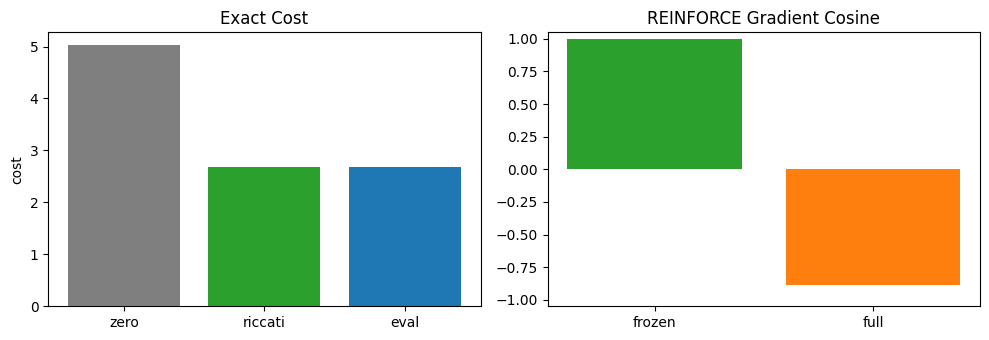

In [8]:
summary_table = pd.DataFrame(
    [
        {
            "metric": "Riccati cost improvement over zero",
            "value": float((cost_zero - cost_riccati).cpu()),
        },
        {
            "metric": "finite-difference gradient max abs error",
            "value": float((exact_grad_eval - finite_diff_grad).abs().max().cpu()),
        },
        {
            "metric": "Monte Carlo cost absolute error",
            "value": float((mc_cost - cost_eval).abs().cpu()),
        },
        {
            "metric": "cos(REINFORCE, frozen-flow gradient)",
            "value": tensor_cosine(reinforce_grad_mean, frozen_grad_eval),
        },
        {
            "metric": "cos(REINFORCE, full mean-field gradient)",
            "value": tensor_cosine(reinforce_grad_mean, exact_grad_eval),
        },
    ]
)
display(summary_table.round(6))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].bar(
    ["zero", "riccati", "eval"],
    [float(cost_zero.cpu()), float(cost_riccati.cpu()), float(cost_eval.cpu())],
    color=["tab:gray", "tab:green", "tab:blue"],
)
axes[0].set_title("Exact Cost")
axes[0].set_ylabel("cost")

axes[1].bar(
    ["frozen", "full"],
    [
        tensor_cosine(reinforce_grad_mean, frozen_grad_eval),
        tensor_cosine(reinforce_grad_mean, exact_grad_eval),
    ],
    color=["tab:green", "tab:orange"],
)
axes[1].set_title("REINFORCE Gradient Cosine")
axes[1].set_ylim(-1.05, 1.05)
plt.tight_layout()
plt.show()
